# Implementing a Simple Momentum Strategy in Python

*Quant Lab · The Analytical Investor · Year 1, Month 10*

**Read the article:** [Implementing a Simple Momentum Strategy in Python](https://analytical-investor.blog/?p=1028)

A cross-sectional 12-2 momentum strategy on 20 simulated assets, measured gross and net of costs, followed by the four audits every backtest deserves.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Simulate, build lookahead-free signals, and backtest with costs.

In [2]:
import numpy as np

rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# 1. Simulate 20 assets, 30 years monthly, with trending behavior
#    Each asset's expected return follows a slow AR(1) "regime"
# ------------------------------------------------------------------
n_assets, n_months = 20, 360
phi, drift_vol, noise_vol = 0.95, 0.004, 0.04

drift = np.zeros((n_assets, n_months))
for t in range(1, n_months):
    drift[:, t] = phi * drift[:, t-1] + rng.normal(0, drift_vol, n_assets)
rets = 0.005 + drift + rng.normal(0, noise_vol, (n_assets, n_months))

# ------------------------------------------------------------------
# 2. Momentum signal: trailing 12-2 return, computed at month end
#    CRITICAL: signal at t uses data through t-1 only (no lookahead)
# ------------------------------------------------------------------
look, skip, top_n = 12, 1, 5
w = np.zeros((n_assets, n_months))
for t in range(look + 1, n_months):
    window = rets[:, t - look - skip : t - skip]      # months t-13..t-2
    signal = (1 + window).prod(axis=1) - 1
    winners = np.argsort(signal)[-top_n:]
    w[winners, t] = 1.0 / top_n                        # equal-weight top 5

# ------------------------------------------------------------------
# 3. Backtest with transaction costs
# ------------------------------------------------------------------
tc = 0.0020                                            # 20 bp per unit turnover
gross = (w * rets).sum(axis=0)
turnover = np.abs(np.diff(w, axis=1, prepend=0)).sum(axis=0)
net = gross - turnover * tc

bench = rets.mean(axis=0)                              # equal-weight universe

def stats(x, label):
    ann_r = (1 + x[13:]).prod() ** (12 / len(x[13:])) - 1
    ann_v = x[13:].std() * np.sqrt(12)
    peak = np.maximum.accumulate(np.cumprod(1 + x[13:]))
    mdd = (np.cumprod(1 + x[13:]) / peak - 1).min()
    print(f"{label:<18} ret {ann_r:6.2%}  vol {ann_v:6.2%}  "
          f"Sharpe {ann_r/ann_v:5.2f}  MaxDD {mdd:6.1%}")

stats(bench, "Buy-and-hold all")
stats(gross, "Momentum (gross)")
stats(net,   "Momentum (net)")
print(f"Avg monthly turnover: {turnover[13:].mean():.0%}")

Buy-and-hold all   ret  4.51%  vol  3.37%  Sharpe  1.34  MaxDD -16.2%
Momentum (gross)   ret 14.05%  vol  6.34%  Sharpe  2.22  MaxDD  -7.0%
Momentum (net)     ret 13.11%  vol  6.35%  Sharpe  2.06  MaxDD  -7.8%
Avg monthly turnover: 35%


### Growth of 1 unit
The gap between gross and net is what trading costs take.

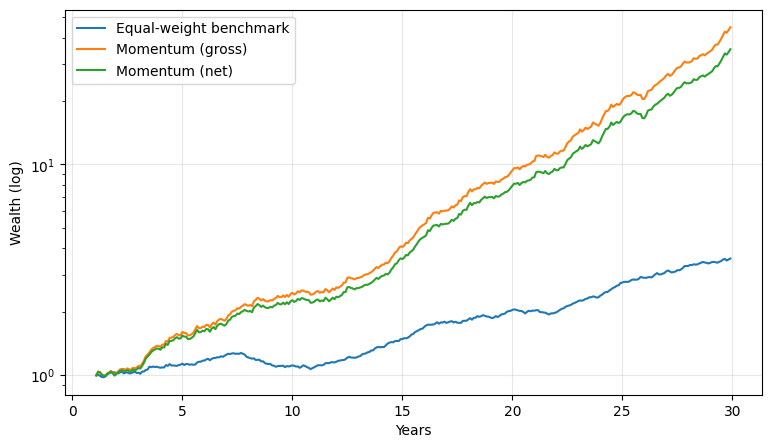

In [3]:
for x, lab in [(bench, "Equal-weight benchmark"), (gross, "Momentum (gross)"), (net, "Momentum (net)")]:
    plt.plot(np.arange(13, n_months) / 12, np.cumprod(1 + x[13:]), label=lab)
plt.yscale("log"); plt.xlabel("Years"); plt.ylabel("Wealth (log)"); plt.legend(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
from analytical_investor import backtest

# Parameter fragility audit from the article
for look in (3, 6, 9, 12):
    w2 = backtest.momentum_weights(rets, lookback=look)
    res = backtest.run_backtest(w2, rets, 0.002)
    print(f"lookback {look:>2}: net mean monthly {res['net'][13:].mean():.3%}")

lookback  3: net mean monthly 0.659%
lookback  6: net mean monthly 0.944%
lookback  9: net mean monthly 1.020%
lookback 12: net mean monthly 1.049%


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1028).